In [1]:
import pandas as pd

titanic = pd.read_csv('./titanic_selena.csv')
titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
pclass_survived_mean = titanic.groupby('Pclass')['Survived'].mean().reset_index()
pclass_survived_mean

,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


In [4]:
import matplotlib.pyplot as plt

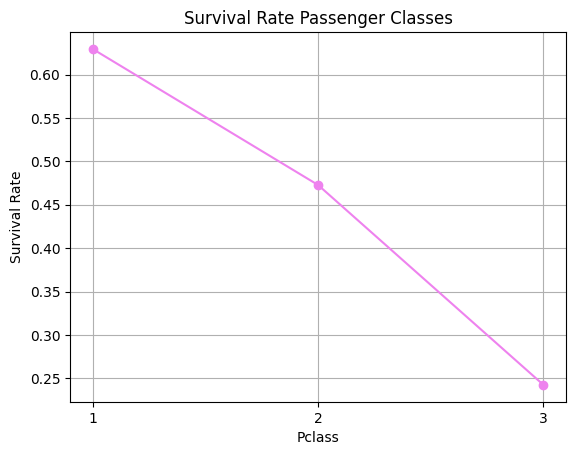

In [ ]:
plt.plot(pclass_survived_mean['Pclass'], pclass_survived_mean['Survived'],
         marker='o', linestyle ='-', color = 'violet'
         )

plt.title('Survival Rate Passenger Classes')
plt.xlabel('Pclass')
plt.ylabel('Survival Rate')
# x 값
plt.xticks([1,2,3])
# 배경에 있는 격자
plt.grid(True)
plt.show()

In [ ]:
# 승선 항구에 따른 생존자의 수 계산
# Embarked(승선한 항)
import numpy as np
import pandas as pd
survived_counts = titanic.groupby('Embarked')['Survived'].value_counts('Survived == 1').reset_index()
survived_counts

AttributeError: 'SeriesGroupBy' object has no attribute 'value'

In [ ]:
# survived == 1 인 애들
# 설명이 더 필요할거같음 아직 잘 이해가 안됨
survived_counts = titanic[titanic['Survived'] == 1]['Embarked'].value_counts()
survived_counts

Embarked
S    217
C     93
Q     30
Name: count, dtype: int64

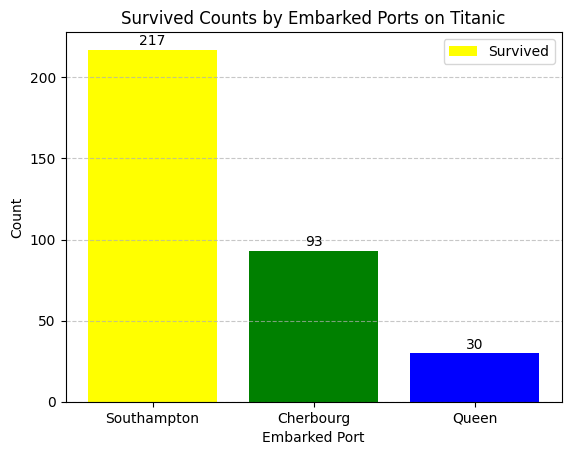

In [58]:
# 막대 그래프 그리기
plt.bar(survived_counts.index, survived_counts, color =['yellow', 'green', 'blue'])
plt.title('Survived Counts by Embarked Ports on Titanic')
plt.xlabel('Embarked Port')
plt.ylabel('Count')
# 하나하나 x축 바꾸기
plt.xticks(survived_counts.index, ['Southampton', 'Cherbourg','Queen'])
# 레전드가 오른쪽 위에 만들어졌따
plt.legend(['Survived'], loc='upper right')
#alpha << 불투명도 
plt.grid(axis='y', linestyle = '--', alpha = 0.7)

#for i, 
for i, value in enumerate(survived_counts):
    # plt.text(x 좌표, y 좌표, 숫자화 시켜주기, )
    plt.text(i, value+1, str(value), ha='center', va='bottom', color='black', fontsize=10)

In [60]:
# 성별에 따른 생존자의 수 계산
survived_counts = titanic[titanic['Survived']==1]['Sex'].value_counts()
survived_counts

Sex
female    233
male      109
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

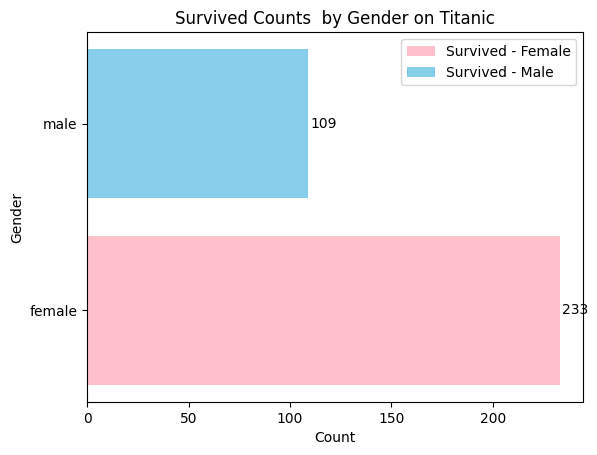

In [76]:
# 수평 막대 그래프 그리기
bars = plt.barh(survived_counts.index, survived_counts, color=['pink','skyblue'])
plt.title("Survived Counts  by Gender on Titanic")
plt.xlabel('Count')
plt.ylabel('Gender')
plt.legend(bars, ['Survived - Female', 'Survived - Male'], loc='upper right')

for i, value in enumerate(survived_counts):
    # plt.text(x 좌표, y 좌표, 숫자화 시켜주기, )
    plt.text(value+1, i, str(value), ha='left', va='center', color='black', fontsize=10)

plt.show


In [108]:
# 결측치 제거 행을 제거 해보자
titanic = titanic.dropna(subset=['Age', 'Fare', 'Survived'])
titanic.info()

<class 'pandas.DataFrame'>
Index: 714 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  714 non-null    int64  
 1   Survived     714 non-null    int64  
 2   Pclass       714 non-null    int64  
 3   Name         714 non-null    str    
 4   Sex          714 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        714 non-null    int64  
 7   Parch        714 non-null    int64  
 8   Ticket       714 non-null    str    
 9   Fare         714 non-null    float64
 10  Cabin        185 non-null    str    
 11  Embarked     712 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 72.5 KB


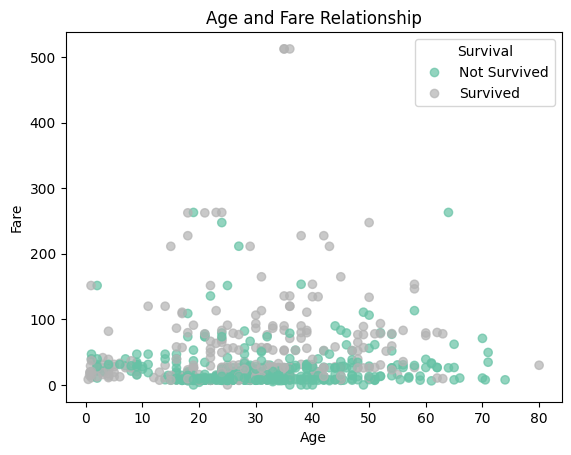

In [90]:
plt.Figure(figsize=(12,8))
#cmap << 색 넣는거
scatter = plt.scatter(x='Age', y='Fare', data=titanic, c=titanic['Survived'], cmap='Set2', alpha=0.7)

plt.title('Age and Fare Relationship')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.legend(handles=scatter.legend_elements()[0], title='Survival', labels=['Not Survived', 'Survived'])

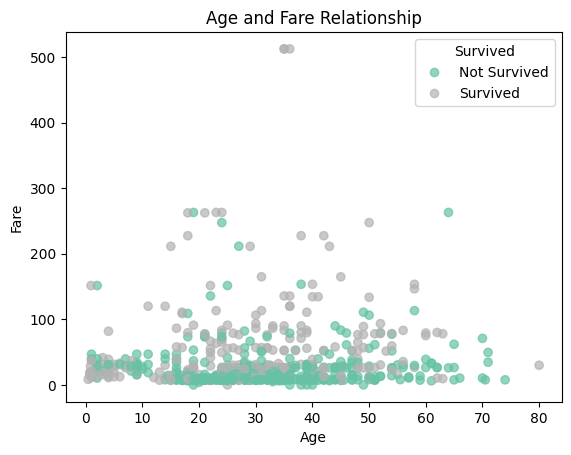

In [143]:
#산점도 그래프 그리기
plt.Figure(figsize=(12, 8))
scatter = plt.scatter(x='Age', y='Fare', data=titanic, c=titanic['Survived'], cmap='Set2', alpha=0.7)

plt.title('Age and Fare Relationship')
plt.xlabel('Age')
plt.ylabel('Fare')
#handles=scatter.legend_elements()[0] => 색상 아이콘
#handles=scatter.legend_elements()[1] => 텍스트 [0, 1]
plt.legend(handles=scatter.legend_elements()[0], title='Survived', labels=['Not Survived', 'Survived'], loc='upper right')
plt.show()

Survived
0    424
1    290
Name: count, dtype: int64

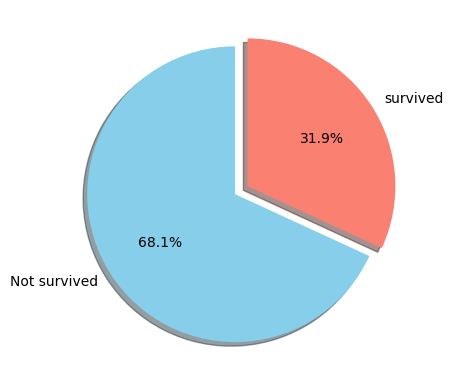

In [112]:
# 살았느냐 죽었느냐 확인 하는 파이그래프를 그리기
# 데이터가 있어야 그래프를 그린다
titanic = titanic.dropna(subset=['Age', 'Fare', 'Survived'])
survival_counts = titanic['Survived'].value_counts()
plt.Figure(figsize=(8,8))
plt.pie(survived_counts, labels=['Not survived', 'survived'], colors=['skyblue', 'salmon'], 
        autopct = '%0.1f%%', explode=(0,0.1), startangle=90, shadow = True)

survival_counts


(array([40., 14., 15., 31., 79., 98., 85., 84., 73., 45., 35., 35., 29.,
        16., 13., 11.,  4.,  5.,  1.,  1.]),
 array([ 0.42 ,  4.399,  8.378, 12.357, 16.336, 20.315, 24.294, 28.273,
        32.252, 36.231, 40.21 , 44.189, 48.168, 52.147, 56.126, 60.105,
        64.084, 68.063, 72.042, 76.021, 80.   ]),
 <BarContainer object of 20 artists>)

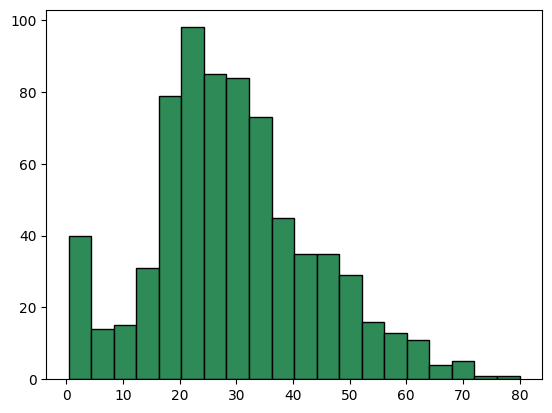

In [115]:
# 히스토그램 그리기 (나이같은것들)
plt.Figure(figsize=(10,6))
plt.hist(titanic['Age'], bins=20, color='seagreen', edgecolor='black')

In [116]:
titanic = pd.read_csv('./titanic_selena.csv')
titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [117]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [118]:
titanic = titanic.dropna(subset=['Age', 'Fare'])
titanic.info()

<class 'pandas.DataFrame'>
Index: 714 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  714 non-null    int64  
 1   Survived     714 non-null    int64  
 2   Pclass       714 non-null    int64  
 3   Name         714 non-null    str    
 4   Sex          714 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        714 non-null    int64  
 7   Parch        714 non-null    int64  
 8   Ticket       714 non-null    str    
 9   Fare         714 non-null    float64
 10  Cabin        185 non-null    str    
 11  Embarked     712 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 72.5 KB


In [121]:
# 서로 서로 상관관계를 비교하가 passengerid는 상관관계가 없다.
titanic = titanic.dropna(subset=['Age', 'Fare'])
# 상관관계를 위해서 만드는 거기때무넹 상관관계가 없으면 날려버린다
# 칼럼과 칼럼간의 상관관계를 해주는 함수가 .corr 이다
correlation_matrix = titanic.drop('PassengerId', axis = 1).corr(numeric_only=True)
correlation_matrix

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.359653,-0.077221,-0.017358,0.093317,0.268189
Pclass,-0.359653,1.000000,-0.369226,0.067247,0.025683,-0.554182
Age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.017358,0.067247,-0.308247,1.000000,0.383820,0.138329
Parch,0.093317,0.025683,-0.189119,0.383820,1.000000,0.205119
Fare,0.268189,-0.554182,0.096067,0.138329,0.205119,1.000000


([<matplotlib.axis.YTick at 0x22486aeead0>,
 [Text(0, 0, 'Survived'),
  Text(0, 1, 'Pclass'),
  Text(0, 2, 'Age'),
  Text(0, 3, 'SibSp'),
  Text(0, 4, 'Parch'),
  Text(0, 5, 'Fare')])

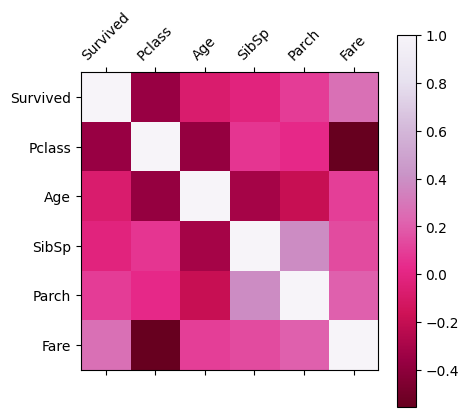

In [ ]:
# 히트맵 그리기
# 히트 맵을 그리기 위해서는 상관관계 매트릭스가 필요하다 
plt.matshow(correlation_matrix, cmap='PuRd_r')
plt.colorbar()

# correlation_matrix.columns Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='str')
# len(correlation_matrix.columns) << 6 range(6) range(0,6) << [0,1,2,3,4,5]
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)


In [131]:
correlation_matrix.columns


Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='str')

In [133]:
titanic = titanic.dropna(subset=['Age'])
titanic.info()

<class 'pandas.DataFrame'>
Index: 714 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  714 non-null    int64  
 1   Survived     714 non-null    int64  
 2   Pclass       714 non-null    int64  
 3   Name         714 non-null    str    
 4   Sex          714 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        714 non-null    int64  
 7   Parch        714 non-null    int64  
 8   Ticket       714 non-null    str    
 9   Fare         714 non-null    float64
 10  Cabin        185 non-null    str    
 11  Embarked     712 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 72.5 KB


{'whiskers': [<matplotlib.lines.Line2D at 0x22486bb3890>,
 'caps': [<matplotlib.lines.Line2D at 0x22486bb3b10>,
 'boxes': [<matplotlib.lines.Line2D at 0x22486bb3750>],
 'medians': [<matplotlib.lines.Line2D at 0x22486bb3d90>],
 'fliers': [<matplotlib.lines.Line2D at 0x22486bb3ed0>],
 'means': []}

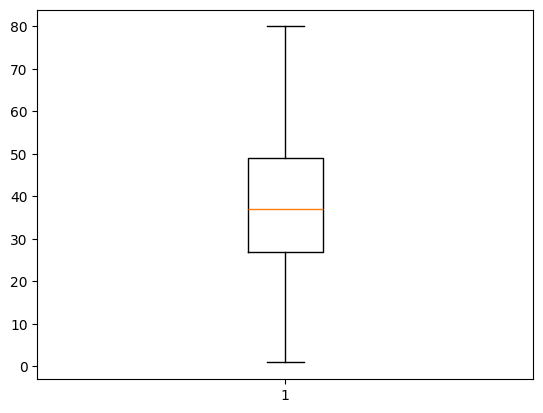

In [139]:
plt.boxplot([titanic[titanic['Pclass'] == 1]['Age']])